<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Clase 5, STL**

Importamos lo necesario

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

Generamos la serie de tiempo

In [ ]:
fechas = pd.date_range(start="2020-01-01", periods=365*3, freq="D")
tendencia = np.linspace(10, 50, len(fechas))
estacionalidad = 10 * np.sin(2 * np.pi * fechas.dayofyear / 365.25)
ruido = np.random.normal(0, 2, len(fechas))

serie = pd.Series(tendencia + estacionalidad + ruido, index=fechas)

Aplicamos STL

In [ ]:
stl = STL(
    serie,
    period=365,      # periodicidad de la estacionalidad
    seasonal=13,     # ventana del suavizado estacional (impar)
    robust=True      # resistente a outliers
)

In [ ]:
resultado = stl.fit()

In [ ]:
tendencia_est = resultado.trend
estacional_est = resultado.seasonal
residuo_est = resultado.resid

Graficamos la descomposición STL (serie, tendencia, estacional, residuo)

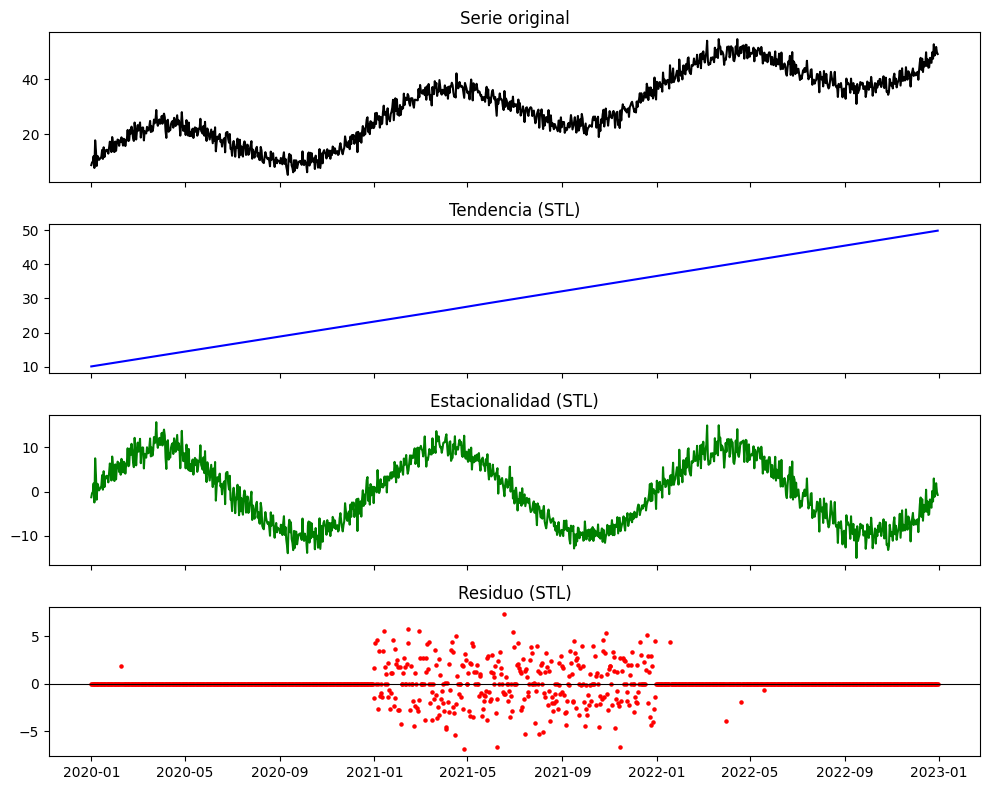

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

axes[0].plot(serie, color="black")
axes[0].set_title("Serie original")

axes[1].plot(tendencia_est, color="blue")
axes[1].set_title("Tendencia (STL)")

axes[2].plot(estacional_est, color="green")
axes[2].set_title("Estacionalidad (STL)")

axes[3].scatter(serie.index, residuo_est, color="red", s=5)
axes[3].axhline(0, color="black", linewidth=0.8)
axes[3].set_title("Residuo (STL)")

plt.tight_layout()
plt.show()

Comparamos las series reales (ground truth) vs las estimadas por STL

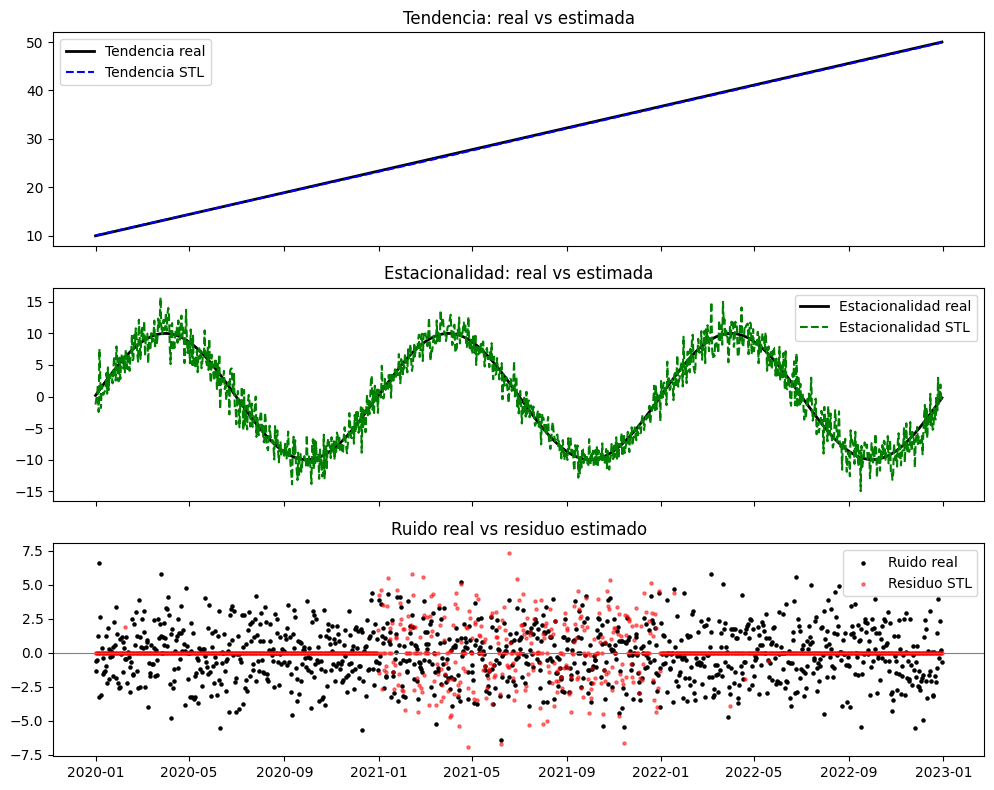

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Tendencia: real vs estimada
axes[0].plot(fechas, tendencia, color="black", linewidth=2, label="Tendencia real")
axes[0].plot(fechas, tendencia_est, color="blue", linestyle="--", label="Tendencia STL")
axes[0].set_title("Tendencia: real vs estimada")
axes[0].legend()

# Estacionalidad: real vs estimada
axes[1].plot(fechas, estacionalidad, color="black", linewidth=2, label="Estacionalidad real")
axes[1].plot(fechas, estacional_est, color="green", linestyle="--", label="Estacionalidad STL")
axes[1].set_title("Estacionalidad: real vs estimada")
axes[1].legend()

#Ruido: real vs estimado (residuo)
axes[2].scatter(fechas, ruido, color="black", s=5, label="Ruido real")
axes[2].scatter(fechas, residuo_est, color="red", s=5, alpha=0.5, label="Residuo STL")
axes[2].axhline(0, color="gray", linewidth=0.8)
axes[2].set_title("Ruido real vs residuo estimado")
axes[2].legend()

plt.tight_layout()
plt.show()

Verificamos que la reconstrucción coincide con la serie original

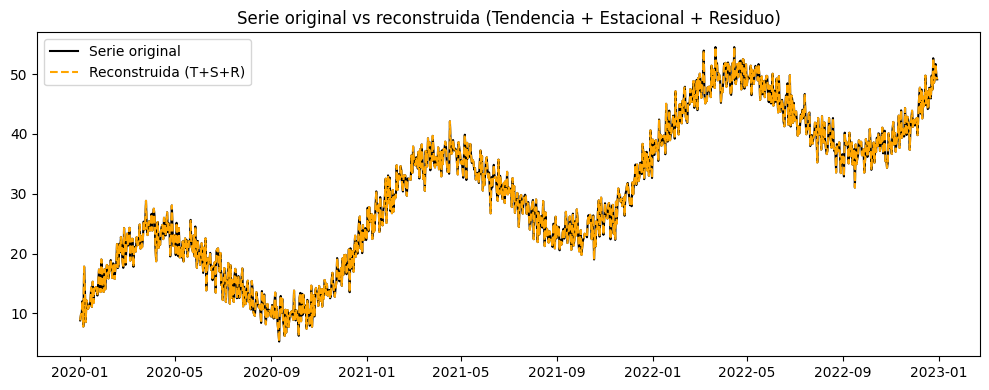

In [ ]:
reconstruida = tendencia_est + estacional_est + residuo_est

plt.figure(figsize=(10, 4))
plt.plot(serie, color="black", label="Serie original")
plt.plot(fechas, reconstruida, color="orange", linestyle="--", label="Reconstruida (T+S+R)")
plt.title("Serie original vs reconstruida (Tendencia + Estacional + Residuo)")
plt.legend()
plt.tight_layout()
plt.show()

Medimos el error

In [ ]:
error_tendencia = np.mean(np.abs(tendencia - tendencia_est))
error_estacional = np.mean(np.abs(estacionalidad - estacional_est))
error_ruido = np.mean(np.abs(ruido - residuo_est))
error_reconstruccion = np.mean(np.abs(serie.values - reconstruida))

print(f"Error absoluto medio - Tendencia:      {error_tendencia:.4f}")
print(f"Error absoluto medio - Estacionalidad:  {error_estacional:.4f}")
print(f"Error absoluto medio - Ruido/Residuo:   {error_ruido:.4f}")
print(f"Error absoluto medio - Reconstrucción:  {error_reconstruccion:.4f}")

Error absoluto medio - Tendencia:      0.1126
Error absoluto medio - Estacionalidad:  1.4803
Error absoluto medio - Ruido/Residuo:   1.4857
Error absoluto medio - Reconstrucción:  0.0000
